In [1]:
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, Slider
import datlib
from scipy.optimize import curve_fit
import os.path

In [2]:
ver = ''

muestra = '5'
fibra = '1'
opt = 'simultaneas'
tipo = 'dextrosa'
titulo = {
    '1':'2h',
    '2':'4h',
    '3':'8h',
    '4':'16h',
    '5':'24h',
    '6':'48h',
}

#MF1\textsubscript{120}
#print(ord('f'))
if fibra == '1':
    pre = ''
if fibra == '2':
    pre = 'f2_'

nomenclatura = []
if opt == 'normales':
    base = 'C:/tesis/Programas/lorentz/normales/'+tipo+'/120/m'
    nomenclatura_base = 'M' + chr(ord(tipo[0])-32) 
    for i in range(6):
        nomenclatura.append(nomenclatura_base+chr(i+49)+'\\textsubscript{120}')
    print(nomenclatura)
else:
    base = 'C:/tesis/Programas/lorentz/simultaneas/'+tipo+'/m'
    nomenclatura_base = 'M' + chr(ord(tipo[0])-32) 
    for i in range(6):
        nomenclatura.append(nomenclatura_base+chr(i+49)+'\\textsubscript{200}')
    print(nomenclatura)
ruta_open = base + muestra +"/"
print(ruta_open + ver +"y0.txt")

['MD1\\textsubscript{200}', 'MD2\\textsubscript{200}', 'MD3\\textsubscript{200}', 'MD4\\textsubscript{200}', 'MD5\\textsubscript{200}', 'MD6\\textsubscript{200}']
C:/tesis/Programas/lorentz/simultaneas/dextrosa/m5/y0.txt


In [3]:
ver = 'o'
if not os.path.isfile(ruta_open +ver +pre+"y0.txt"):
    ver = ''
    print('ver ', i)
else:
    print('ver o', i)



y0 = np.loadtxt(ruta_open + ver+ pre+"y0.txt", delimiter = ",")

wid1 = np.loadtxt(ruta_open + ver +pre+"wid1.txt", delimiter = ",")
wid2 = np.loadtxt(ruta_open + ver +pre+ "wid2.txt", delimiter = ",")
wid3 = np.loadtxt(ruta_open + ver + pre+"wid3.txt", delimiter = ",")

amp1 = np.loadtxt(ruta_open + ver + pre+"amp1.txt", delimiter = ",")
amp2 = np.loadtxt(ruta_open + ver + pre+"amp2.txt", delimiter = ",")
amp3 = np.loadtxt(ruta_open + ver + pre+"amp3.txt", delimiter = ",")

lambda0_1 = np.loadtxt(ruta_open + ver + pre+"lambda1.txt", delimiter = ",")
lambda0_2 = np.loadtxt(ruta_open + ver + pre+"lambda2.txt", delimiter = ",")
lambda0_3 = np.loadtxt(ruta_open + ver + pre+"lambda3.txt", delimiter = ",")

datos = np.loadtxt(ruta_open + ver + pre+"datos.txt", delimiter = ",")
wavelength = np.loadtxt(ruta_open + ver + pre+"wavelength.txt", delimiter = ",")

name1 =  f"{lambda0_1[0]:.0f}"
name2 =  f"{lambda0_2[0]:.0f}"
name3 =  f"{lambda0_3[0]:.0f}"
print(ruta_open + ver + pre+"datos.txt")

ver o 5
C:/tesis/Programas/lorentz/simultaneas/dextrosa/m5/odatos.txt


In [4]:
if False:
    np.savetxt(ruta_open + 'amp1fixed.txt', amp1, delimiter=',')
    np.savetxt(ruta_open + 'amp3fixed.txt', amp3, delimiter=',')
    np.savetxt(ruta_open + 'paramsfitfixed.txt', params_fit, delimiter=',')

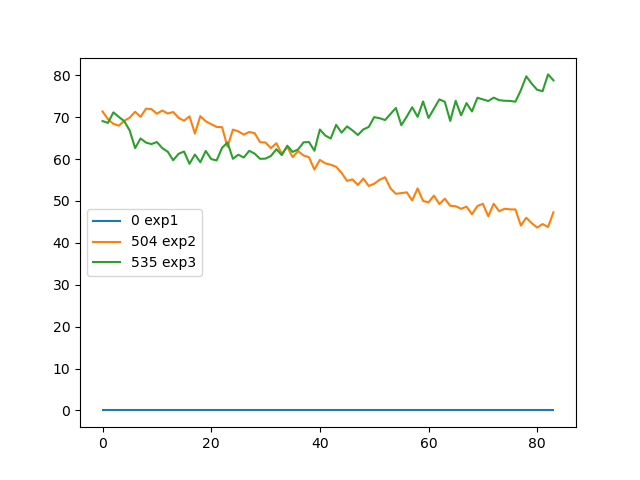

In [5]:
cut = len(datos)
#cut = 48
bottom = 0
plt.figure()
"""
plt.plot(lambda0_1[bottom:cut], '-', label=name1 +' exp')

plt.plot(lambda0_2[bottom:cut], '-', label=name2 +' exp')

plt.plot(lambda0_3[bottom:cut], '-', label=name3 +' exp')
"""

plt.plot(amp1[bottom:cut], '-', label=name1 +' exp1')

plt.plot(amp2[bottom:cut], '-', label=name2 +' exp2')

plt.plot(amp3[bottom:cut], '-', label=name3 +' exp3')

plt.legend()
plt.show()

In [6]:
def lotkavolterra(t, z, a, b, c, d):
    x, y = z
    return [a*x - b*x*y, -c*y + d*x*y]

def solve_model(t, params, x0, y0):
    alpha, beta, delta, gamma = params
    
    sol = solve_ivp(
        lotkavolterra,
        [t[0], t[-1]],
        [x0, y0],
        t_eval=t,
        args=(alpha, beta, delta, gamma)
    )
    
    return sol.y
def residuals(params, t, x_exp, y_exp):
    x0, y0 = x_exp[0], y_exp[0]
    x_model, y_model = solve_model(t, params, x0, y0)
    
    return np.concatenate([
        x_model - x_exp,
        y_model - y_exp
    ])

In [7]:
def solve_model(t, params, x0, y0, z0):

    sol = solve_ivp(
        lv3,
        [t[0], t[-1]],
        [x0, y0,z0],
        t_eval=t,
        args=params
    )
    return sol.y
    
def residuals(params, t, x_exp, y_exp, z_exp):
    x0, y0, z0 = x_exp[0], y_exp[0], z_exp[0]
    x_model, y_model, z_model = solve_model(t, params, x0, y0, z0)
    
    return np.concatenate([
        x_model - x_exp,
        y_model - y_exp,
        z_model - z_exp
    ])

$$
\frac{dx}{dt} = x(-a - b y - c z) - d x y z + e
$$

$$
\frac{dy}{dt} = y(-f + g x - h z) - i x y z + j
$$

$$
\frac{dz}{dt} = z(-k + l x + m y) - n x y z + o
$$

donde $x(t) = 470$, $y(t) = 500$, $z(t) = 530$ 

In [8]:
def lv3(t, med, a, b, c, d, e, f, g, h, i, j, k, l, m, n, o):
    x, y, z = med
    
    return [
        x*(-a - b*y -c*z )  -d*x*y*z + e,
        y*(-f + g*x - h*z ) -i*x*y*z + j,
        z*(-k + l*x + m*y) - n*x*y*z + o
    ]

$$
\frac{dx}{dt} = x(-a - b y - c z) + e
$$

$$
\frac{dy}{dt} = y(-d + f x - g z) + j
$$

$$
\frac{dz}{dt} = z(-h - i xy + k y) + o
$$

donde $x(t) = 470$, $y(t) = 500$, $z(t) = 530$ 

In [9]:
def lv3(t, med, a, b, c, d, e, f, g, h, i, j, k, l, m, n, o):
    x, y, z = med
    
    return [
        x*(-a -b*y - c*z)  + e, 
        y*(-d + f*x - g*z) + j, 
        z*(-h -i*x*y + k*y) + o]

In [10]:
tam = cut-bottom
t_data = np.linspace(0, tam/84, tam)     
x_data = amp1[bottom:cut] #-np.mean(amp1)
#x_data+= abs(min(x_data))
y_data = amp2[bottom:cut] # np.mean(amp2)
#y_data += abs(min(y_data))
z_data = amp3[bottom:cut] #- np.mean(amp3)
#z_data += abs(min(z_data))


p0 = [0.0, 0.1,1.0,0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,0.0, 0.0, 0.0, 0.0, 0.0]

result = least_squares(
    residuals,
    p0,
    bounds=([0,0,0,0,-10,0,0,0,0, -10,0,0,0,0,0],[10,10,10,10,10,10,10,10,10, 10,10,10, 10, 10, 10]),
    args=(t_data, x_data, y_data, z_data)
)

params_fit = result.x

for i in range(3):
    print("Para", chr(120+i) ,": ")
    for j in range(5):
        print(chr(j+97 + i*5) + ": ", params_fit[j+i*5], " ")
    print("\n")

Para x : 
a:  8.848220286602727  
b:  1.2604836545080451e-17  
c:  9.999997203137571  
d:  3.7826270974692537e-13  
e:  8.042139649132842  


Para y : 
f:  3.2423969353271453  
g:  0.004447556177659365  
h:  1.2195474759084877e-09  
i:  7.539902770939799  
j:  -9.999724535193968  


Para z : 
k:  0.08384113497378796  
l:  0.10894696591245086  
m:  1e-10  
n:  1e-10  
o:  9.999999980797512  




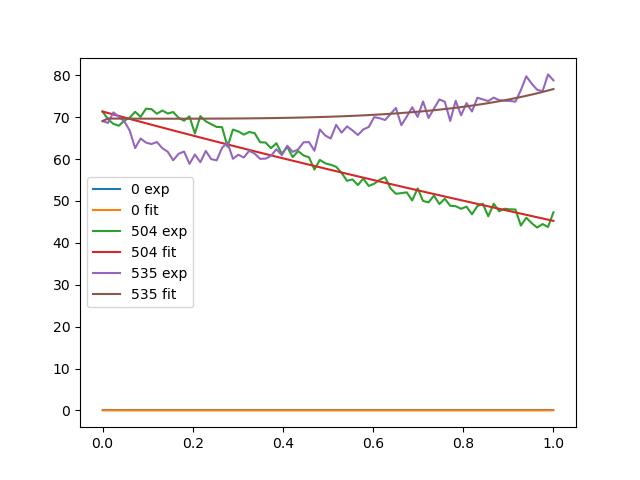

In [11]:
x_fit, y_fit, z_fit = solve_model(t_data, params_fit, x_data[0], y_data[0], z_data[0])

plt.figure()
plt.plot(t_data, x_data, '-', label=name1 +' exp')
plt.plot(t_data, x_fit, '-', label=name1 +' fit')
plt.plot(t_data, y_data, '-', label=name2 +' exp')
plt.plot(t_data, y_fit, '-', label=name2 +' fit')
plt.plot(t_data, z_data, '-', label=name3 +' exp')
plt.plot(t_data, z_fit, '-', label=name3 +' fit')
#agregar etiquetas adecuadas como candidatos para la tesis


plt.legend()
plt.show()

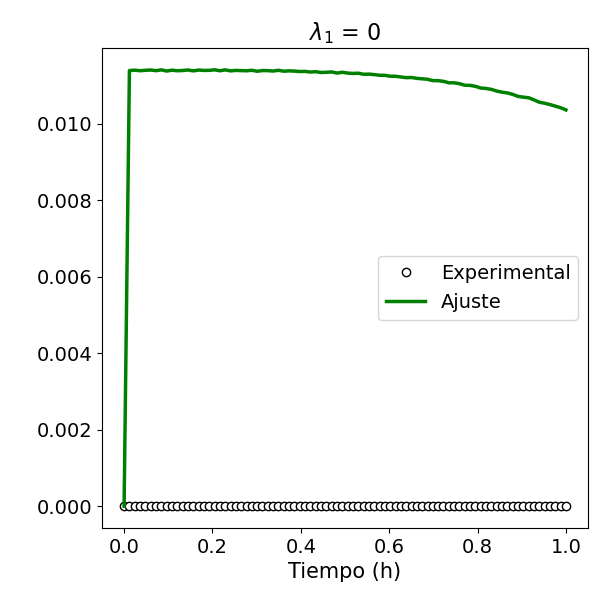

In [12]:
#plt.figure()
fig, ax = plt.subplots(figsize=(6,6))
plt.subplots_adjust(left=0.17, right=0.98, top=0.92, bottom=0.12)

ax.plot(t_data, x_data, marker = 'o', linestyle = '', mfc='white', mec='black')
ax.plot(t_data, x_fit, '-', color = 'green', lw=2.5)
ax.set_xlabel("Tiempo (h)", fontsize = 15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(['Experimental', 'Ajuste'], fontsize=14)
ax.set_title(r'$\lambda_{1}$ = '+ name1, fontsize = 16)
plt.show()

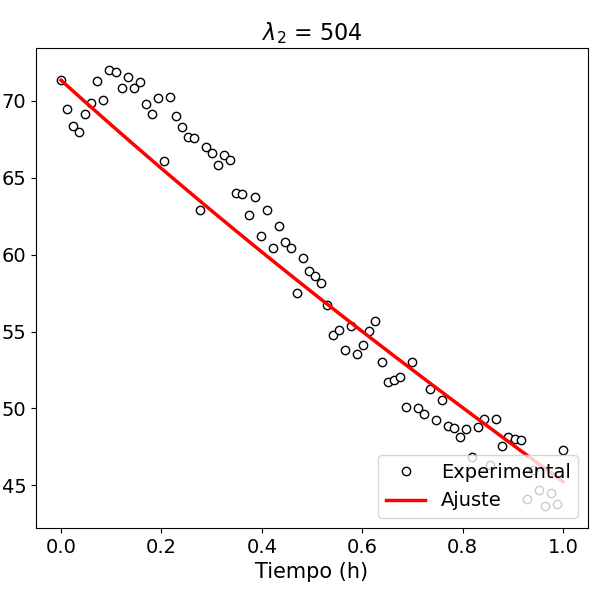

In [13]:
fig, ax = plt.subplots(figsize=(6,6))
plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.12)
#ax.set_ylim(bottom = 0, top = 110)
ax.plot(t_data, y_data, marker = 'o', linestyle = '', mfc='white', mec='black')
ax.plot(t_data, y_fit, '-', color = 'red',lw=2.5)
ax.set_xlabel("Tiempo (h)", fontsize = 15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(['Experimental', 'Ajuste'], fontsize=14, loc='lower right')
ax.set_title(r'$\lambda_{2}$ = '+ name2, fontsize = 16)
plt.show()

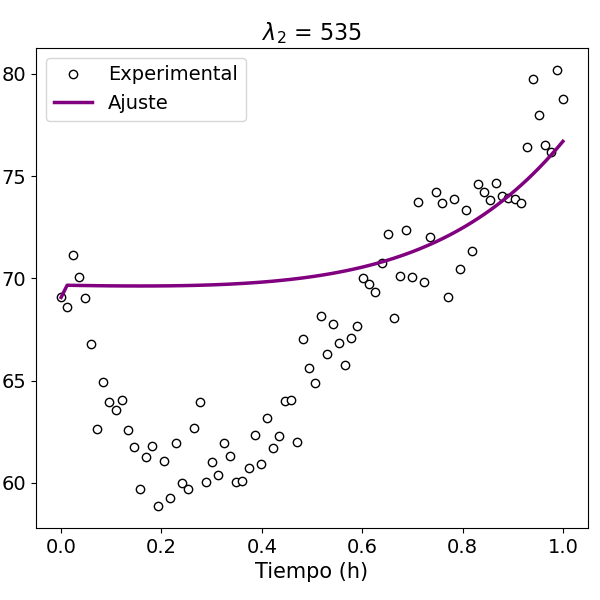

In [14]:
fig, ax = plt.subplots(figsize=(6,6))
plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.12)

ax.plot(t_data, z_data, marker = 'o', linestyle = '', mfc='white', mec='black')
ax.plot(t_data, z_fit, '-', color = 'purple',lw=2.5)
ax.set_xlabel("Tiempo (h)", fontsize = 15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(['Experimental', 'Ajuste'], fontsize=14)
ax.set_title(r'$\lambda_{2}$ = '+ name3, fontsize = 16)
plt.show()

In [41]:
def lv3(t, med, a, b, c, d, e, f):
    x, y= med
    return [
        x*(-a -b*y)  + e, 
        y*(-c - d*x) + f]

def solve_model(t, params, x0, y0):
    a,b,c,d,e,f = params
    
    sol = solve_ivp(
        lv3,
        [t[0], t[-1]],
        [x0, y0],
        t_eval=t,
        args=(a,b,c,d,e,f)
    )
    
    return sol.y
def residuals(params, t, x_exp, y_exp):
    x0, y0 = x_exp[0], y_exp[0]
    x_model, y_model = solve_model(t, params, x0, y0)

    return np.concatenate([
        x_model - x_exp,
        y_model - y_exp
    ])

In [44]:
bottom = 0
tam = cut - bottom
t_data = np.linspace(0, tam/84, tam)*10
#x_data = amp2[bottom:cut] 
#y_data = amp3[bottom:cut] 
x_data = np.copy(amp2[bottom:cut])
y_data = np.copy(amp3[bottom:cut] )
"""
for i in range(41):
    x_data[i] += 0.9
    y_data[i] -= 0.9
    amp1[i+1] += 0.9
    amp2[i+1] -= 0.9"""
#print(t_data.shape)
#print(t_data[0], t_data[-1])

p0 = [0.1,1.0, 0.0, 0.0, 0.0, 0.0]

result = least_squares(
    residuals,
    p0,
    bounds=([0,0,0,0,0,0],[10,10,10,10, 100, 100]),
    args=(t_data, x_data, y_data)
)

params_fit = result.x

for i in range(1):
    print("Para", chr(120+i) ,": ")
    for j in range(6):
        print(chr(j+97 + i*5) + ": ", params_fit[j+i*5], " ")
    print("\n")

Para x : 
a:  1.884286095499482e-18  
b:  0.0006774467531040654  
c:  0.05211934747471544  
d:  0.010537961076052394  
e:  8.28533674142039e-16  
f:  45.187852689557204  




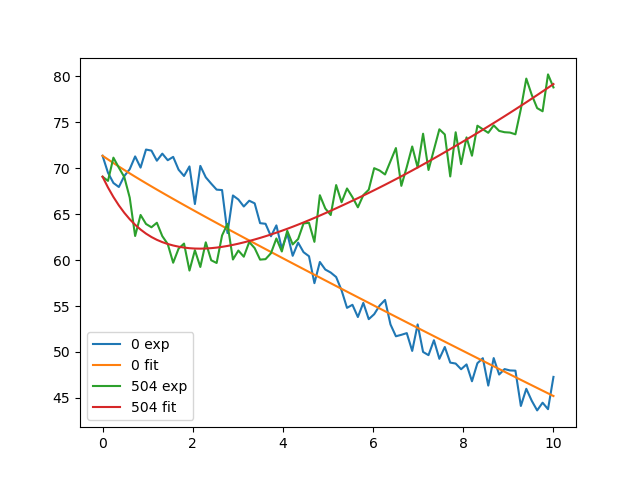

In [45]:
x_fit, y_fit = solve_model(t_data, params_fit, x_data[0], y_data[0])

plt.figure()
plt.plot(t_data, x_data, '-', label=name1 +' exp')
plt.plot(t_data, x_fit, '-', label=name1 +' fit')
plt.plot(t_data, y_data, '-', label=name2 +' exp')
plt.plot(t_data, y_fit, '-', label=name2 +' fit')


plt.legend()
plt.show()

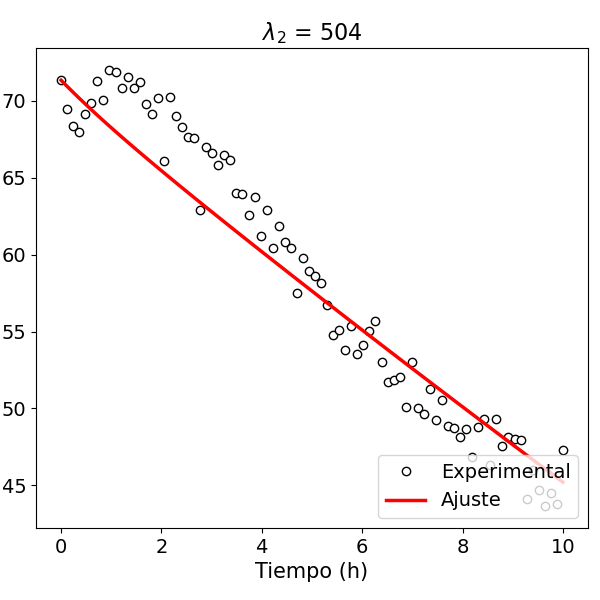

In [46]:
fig, ax = plt.subplots(figsize=(6,6))
plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.12)
#ax.set_ylim(bottom = 0, top = 110)
ax.plot(t_data, x_data, marker = 'o', linestyle = '', mfc='white', mec='black')
ax.plot(t_data, x_fit, '-', color = 'red',lw=2.5)
ax.set_xlabel("Tiempo (h)", fontsize = 15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(['Experimental', 'Ajuste'], fontsize=14, loc='lower right')
ax.set_title(r'$\lambda_{2}$ = '+ name2, fontsize = 16)
plt.show()

C:\Users\jevmq\AppData\Local\Temp\ipykernel_11376\2289666766.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6,6))


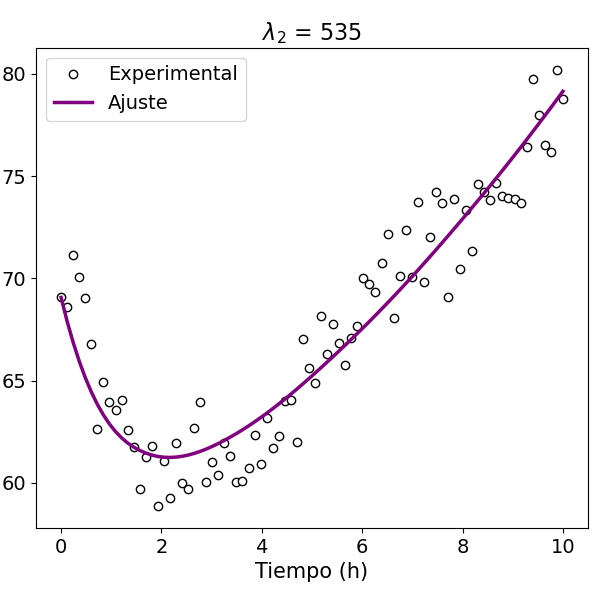

In [47]:
fig, ax = plt.subplots(figsize=(6,6))
plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.12)

ax.plot(t_data, y_data, marker = 'o', linestyle = '', mfc='white', mec='black')
ax.plot(t_data, y_fit, '-', color = 'purple',lw=2.5)
ax.set_xlabel("Tiempo (h)", fontsize = 15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(['Experimental', 'Ajuste'], fontsize=14)
ax.set_title(r'$\lambda_{2}$ = '+ name3, fontsize = 16)
plt.show()

In [48]:
ver = 'o'

In [49]:
np.savetxt(ruta_open + ver + pre+'paramsfit.txt', params_fit, delimiter=',')
np.savetxt(ruta_open + ver + pre+'cut.txt', np.array([cut]), delimiter=',')
np.savetxt(ruta_open + ver + pre+'bottom.txt', np.array([bottom]), delimiter=',')

In [293]:
print(ruta_open + ver + pre+'paramsfit.txt')

C:/tesis/Programas/lorentz/simultaneas/dextrosa/m5/oparamsfit.txt


In [241]:
np.savetxt(ruta_open + ver + pre+"amp2.txt", amp2, delimiter=',')
np.savetxt(ruta_open + ver + pre+"amp1.txt", amp1, delimiter=',')